#### (5 pts) Look up the Adam optimization functions in PyTorch https://pytorch.org/docs/stable/optim.html . How does it work? Try at least one other optimization function with the diabetes dataset shown in class. How does the model perform with the new optimizer? Did it perform better or worse than Adam? Why do you think that is?

The Adam optimization function does a type of backward propagation. It goes through each layer searching for the changes that result in the smallest difference between the predicted data and the actual data. It takes gradients of each layer as it goes. 

In [6]:
import pandas as pd
import torch

diabetes_df = pd.read_csv('diabetes.csv')
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
from sklearn.model_selection import train_test_split
X = diabetes_df.drop('Outcome', axis = 1).values
y = diabetes_df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, 
                                                    random_state = 50, stratify = y)

In [10]:
import torch.nn as nn
import torch.nn.functional as F #function has activation functions
#create tensors from the data
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

print(X_train)

ValueError: could not determine the shape of object type 'Series'

In [11]:
class ANN_Model(nn.Module):
    def __init__(self, input_features=8, 
                 hidden1=20, hidden2=20, 
                 out_features=2):
        super().__init__()
        
        self.layer_1_connection = nn.Linear(input_features, hidden1)
        self.layer_2_connection = nn.Linear(hidden1, hidden2)
        self.out = nn.Linear(hidden2, out_features)

    def forward(self, x):
        
        x = F.relu(self.layer_1_connection(x))
        x = F.relu(self.layer_2_connection(x))
        x = self.out(x)
        return x

In [12]:
torch.manual_seed(50)
ann=ANN_Model()

In [13]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.ASGD(ann.parameters(), lr = 0.01)

In [14]:
final_loss = []
n_epochs = 500
for epoch in range(n_epochs):
    y_pred = ann.forward(X_train)
    loss = loss_function(y_pred, y_train)
    final_loss.append(loss)

    if epoch % 10 == 1:
        print(f'Epoch number: {epoch} with loss {loss}')

    optimizer.zero_grad() 
    loss.backward()
    optimizer.step() 

Epoch number: 1 with loss 8.74705696105957
Epoch number: 11 with loss 0.6815722584724426
Epoch number: 21 with loss 0.6477150917053223
Epoch number: 31 with loss 0.6321315169334412
Epoch number: 41 with loss 0.6208236813545227
Epoch number: 51 with loss 0.6145395636558533
Epoch number: 61 with loss 0.611413300037384
Epoch number: 71 with loss 0.6081092357635498
Epoch number: 81 with loss 0.6054947972297668
Epoch number: 91 with loss 0.6028326153755188
Epoch number: 101 with loss 0.5995239019393921
Epoch number: 111 with loss 0.5962029099464417
Epoch number: 121 with loss 0.5945510864257812
Epoch number: 131 with loss 0.5927437543869019
Epoch number: 141 with loss 0.5914831161499023
Epoch number: 151 with loss 0.590705931186676
Epoch number: 161 with loss 0.589842677116394
Epoch number: 171 with loss 0.5894886255264282
Epoch number: 181 with loss 0.5880882740020752
Epoch number: 191 with loss 0.5871440768241882
Epoch number: 201 with loss 0.5861935615539551
Epoch number: 211 with loss 0

In [16]:
y_pred = []
with torch.no_grad(): 
    for i, data in enumerate(X_test):
        prediction = ann(data)
        y_pred.append(prediction.argmax())

ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (233).

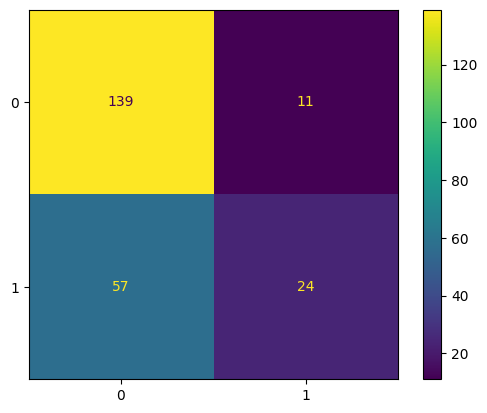

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [22]:
24/(24+57)

"""
The ASGD didn't perform nearly as well as the Adam optimizer. 
This seems like it is because ASGD is such a simpler optimizer 
than Adam. It is not as robust and so it cannot handle larger
datasets well.
"""

"\nThe ASGD didn't perform nearly as well as the Adam optimizer. \nThis seems like it is because ASGD is such a simpler optimizer \nthan Adam. It is not as robust and so it cannot handle larger\ndatasets well.\n"

In [ ]:
"""
takes in a number and spits out all of the numbers that go in to that number evenly
"""
factors_count = 0
factors = []
def divisors(num):
    for i in range(num-1):
        if num%i == 0: 
            factors.append(i)
            factors_count += 1
        
    return(f"There are {factors_count} divisors. {factors}")